In [1]:
!pip -q install psycopg2-binary pandas neo4j requests sqlparse sqlalchemy tqdm

In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip -q install psycopg2-binary pandas neo4j requests sqlparse sqlalchemy tqdm

In [4]:
import os, json, re, time, hashlib
import pandas as pd
import requests
import sqlparse
from tqdm import tqdm
from neo4j import GraphDatabase
import psycopg2

In [5]:
PG_HOST = os.getenv("PG_HOST", "localhost")
PG_PORT = int(os.getenv("PG_PORT", "5432"))
PG_DB   = os.getenv("PG_DB", "customer_orders_and_reviews_db")
PG_USER = os.getenv("PG_USER", "postgres")
PG_PASS = os.getenv("PG_PASS", "postgres")

NEO4J_URI  = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASS = os.getenv("NEO4J_PASS", "neo4jpassword")

OLLAMA_URL = os.getenv("OLLAMA_URL", "http://localhost:11434")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "gemma3:4b")  # or gemma2:9b etc

In [6]:
import psycopg2

pg_conn = psycopg2.connect(
    host=PG_HOST, port=PG_PORT, dbname=PG_DB, user=PG_USER, password=PG_PASS
)
pg_conn.autocommit = True

In [7]:
def fetch_df(query, params=None):
    return pd.read_sql_query(query, pg_conn, params=params)

In [8]:
schemas = fetch_df("""
SELECT schema_name
FROM information_schema.schemata
WHERE schema_name NOT IN ('pg_catalog','information_schema')
ORDER BY schema_name;
""")

print("Schemas loaded:", len(schemas))

Schemas loaded: 2


/var/folders/75/bzqf62356_l1pth2cm_p2vm00000gn/T/ipykernel_93181/3784579659.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, pg_conn, params=params)


In [9]:
tables = fetch_df("""
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type='BASE TABLE'
  AND table_schema NOT IN ('pg_catalog','information_schema')
ORDER BY table_schema, table_name;
""")

print("Tables loaded:", len(tables))
tables.head()

Tables loaded: 5


/var/folders/75/bzqf62356_l1pth2cm_p2vm00000gn/T/ipykernel_93181/3784579659.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, pg_conn, params=params)


,table_schema,table_name
0,public,customers
1,public,order_items
2,public,orders
3,public,products
4,public,reviews


In [10]:
columns = fetch_df("""
SELECT table_schema,
       table_name,
       column_name,
       data_type,
       is_nullable
FROM information_schema.columns
WHERE table_schema NOT IN ('pg_catalog','information_schema')
ORDER BY table_schema, table_name, ordinal_position;
""")

print("Columns loaded:", len(columns))
columns.head()

Columns loaded: 39


/var/folders/75/bzqf62356_l1pth2cm_p2vm00000gn/T/ipykernel_93181/3784579659.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, pg_conn, params=params)


,table_schema,table_name,column_name,data_type,is_nullable
0,public,customers,customer_id,uuid,NO
1,public,customers,first_name,character varying,NO
2,public,customers,last_name,character varying,NO
3,public,customers,email,character varying,NO
4,public,customers,phone,character varying,YES


In [11]:
pk = fetch_df("""
SELECT
  tc.table_schema,
  tc.table_name,
  kcu.column_name
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
  ON tc.constraint_name = kcu.constraint_name
 AND tc.table_schema = kcu.table_schema
WHERE tc.constraint_type='PRIMARY KEY'
  AND tc.table_schema NOT IN ('pg_catalog','information_schema')
ORDER BY tc.table_schema, tc.table_name;
""")

print("PK rows:", len(pk))

PK rows: 5


/var/folders/75/bzqf62356_l1pth2cm_p2vm00000gn/T/ipykernel_93181/3784579659.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, pg_conn, params=params)


In [12]:
fk = fetch_df("""
SELECT
  tc.table_schema,
  tc.table_name,
  kcu.column_name,
  ccu.table_schema AS ref_schema,
  ccu.table_name AS ref_table,
  ccu.column_name AS ref_column,
  tc.constraint_name
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
  ON tc.constraint_name = kcu.constraint_name
 AND tc.table_schema = kcu.table_schema
JOIN information_schema.constraint_column_usage ccu
  ON ccu.constraint_name = tc.constraint_name
 AND ccu.table_schema = tc.table_schema
WHERE tc.constraint_type='FOREIGN KEY'
  AND tc.table_schema NOT IN ('pg_catalog','information_schema')
ORDER BY tc.table_schema, tc.table_name;
""")

print("FK rows:", len(fk))

FK rows: 5


/var/folders/75/bzqf62356_l1pth2cm_p2vm00000gn/T/ipykernel_93181/3784579659.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, pg_conn, params=params)


In [13]:
print("schemas exists:", "schemas" in globals())
print("tables exists:", "tables" in globals())
print("columns exists:", "columns" in globals())
print("pk exists:", "pk" in globals())
print("fk exists:", "fk" in globals())

schemas exists: True
tables exists: True
columns exists: True
pk exists: True
fk exists: True


In [14]:
from neo4j import GraphDatabase

neo_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

def neo_run(cypher, params=None):
    with neo_driver.session() as session:
        return session.run(cypher, params or {}).data()

In [15]:
neo_run("MATCH (n) DETACH DELETE n")

neo_run("CREATE CONSTRAINT schema_name IF NOT EXISTS FOR (s:Schema) REQUIRE s.name IS UNIQUE")
neo_run("CREATE CONSTRAINT table_full IF NOT EXISTS FOR (t:Table) REQUIRE t.full_name IS UNIQUE")
neo_run("CREATE CONSTRAINT column_full IF NOT EXISTS FOR (c:Column) REQUIRE c.full_name IS UNIQUE")

[]

In [16]:
# schemas
for s in schemas["schema_name"].tolist():
    neo_run("MERGE (:Schema {name:$name})", {"name": s})

# tables
for _, r in tables.iterrows():
    full = f"{r.table_schema}.{r.table_name}"
    neo_run("""
    MATCH (s:Schema {name:$schema})
    MERGE (t:Table {full_name:$full})
    SET t.schema=$schema, t.name=$name
    MERGE (s)-[:HAS_TABLE]->(t)
    """, {"schema": r.table_schema, "name": r.table_name, "full": full})

# columns
for _, r in columns.iterrows():
    t_full = f"{r.table_schema}.{r.table_name}"
    c_full = f"{t_full}.{r.column_name}"
    neo_run("""
    MATCH (t:Table {full_name:$t_full})
    MERGE (c:Column {full_name:$c_full})
    SET c.schema=$schema, c.table=$table, c.name=$col,
        c.data_type=$dtype, c.nullable=$nullable
    MERGE (t)-[:HAS_COLUMN]->(c)
    """, {
        "t_full": t_full,
        "c_full": c_full,
        "schema": r.table_schema,
        "table": r.table_name,
        "col": r.column_name,
        "dtype": r.data_type,
        "nullable": (r.is_nullable == "YES")
    })

In [17]:
for _, r in pk.iterrows():
    c_full = f"{r.table_schema}.{r.table_name}.{r.column_name}"
    t_full = f"{r.table_schema}.{r.table_name}"
    neo_run("""
    MATCH (c:Column {full_name:$c_full})
    MATCH (t:Table {full_name:$t_full})
    SET c.is_pk = true
    MERGE (c)-[:PK_OF]->(t)
    """, {"c_full": c_full, "t_full": t_full})

In [18]:
for _, r in fk.iterrows():
    src = f"{r.table_schema}.{r.table_name}.{r.column_name}"
    dst = f"{r.ref_schema}.{r.ref_table}.{r.ref_column}"
    neo_run("""
    MATCH (c1:Column {full_name:$src})
    MATCH (c2:Column {full_name:$dst})
    MERGE (c1)-[:FK_TO {constraint:$cname}]->(c2)
    """, {"src": src, "dst": dst, "cname": r.constraint_name})

In [19]:
neo_run("MATCH (t:Table) RETURN count(t) AS tables"), neo_run("MATCH (c:Column) RETURN count(c) AS cols")

([{'tables': 5}], [{'cols': 39}])

In [20]:
def build_schema_context(limit_tables=50):
    # grab tables + columns + PK + FK
    data = neo_run("""
    MATCH (t:Table)-[:HAS_COLUMN]->(c:Column)
    WITH t, collect({
        name: c.name, type: c.data_type, nullable: c.nullable, is_pk: coalesce(c.is_pk,false)
    }) AS cols
    RETURN t.full_name AS table, cols
    ORDER BY table
    LIMIT $limit
    """, {"limit": limit_tables})
    
    fk_data = neo_run("""
    MATCH (c1:Column)-[r:FK_TO]->(c2:Column)
    RETURN c1.full_name AS from_col, c2.full_name AS to_col
    LIMIT 200
    """)
    
    lines = []
    for row in data:
        lines.append(f"TABLE {row['table']}")
        for col in row["cols"]:
            pk_tag = " PK" if col["is_pk"] else ""
            nn_tag = " NOT_NULL" if (col["nullable"] is False) else ""
            lines.append(f"  - {col['name']} ({col['type']}){pk_tag}{nn_tag}")
    if fk_data:
        lines.append("\nFOREIGN_KEYS")
        for r in fk_data:
            lines.append(f"  - {r['from_col']} -> {r['to_col']}")
    return "\n".join(lines)

schema_context = build_schema_context(limit_tables=200)
print(schema_context[:2000])

TABLE public.customers
  - created_at (timestamp without time zone)
  - zip_code (character varying)
  - country (character varying)
  - state (character varying)
  - city (character varying)
  - address (text)
  - phone (character varying)
  - email (character varying) NOT_NULL
  - last_name (character varying) NOT_NULL
  - first_name (character varying) NOT_NULL
  - customer_id (uuid) PK NOT_NULL
TABLE public.order_items
  - created_at (timestamp without time zone)
  - subtotal (numeric) NOT_NULL
  - unit_price (numeric) NOT_NULL
  - quantity (integer) NOT_NULL
  - product_id (uuid) NOT_NULL
  - order_id (uuid) NOT_NULL
  - order_item_id (uuid) PK NOT_NULL
TABLE public.orders
  - notes (text)
  - shipping_address (text)
  - total_amount (numeric) NOT_NULL
  - status (character varying) NOT_NULL
  - order_date (timestamp without time zone)
  - customer_id (uuid) NOT_NULL
  - order_id (uuid) PK NOT_NULL
TABLE public.products
  - updated_at (timestamp without time zone)
  - created_at (

In [21]:
!pip -q install ollama sqlparse tqdm psycopg2-binary

In [22]:
import os, json, re, time, hashlib
import pandas as pd
import psycopg2
import sqlparse
import ollama
from tqdm import tqdm

import datetime
import decimal
import uuid

In [23]:
CSV_PATH = "final_test_data.csv"   # update if needed
OUT_REPORT = "nl2sql_test_report_with_results_basic.csv"
OUT_SUMMARY = "nl2sql_test_report_summary_basic.csv"

# Ollama
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "gemma3:4b")  # e.g. gemma2:9b
TEMPERATURE = 0.1

# Execution sampling
FETCH_ROWS = 20   # rows stored in report (sample)

In [24]:
df_tests = pd.read_csv(CSV_PATH)

def parse_params(x):
    if pd.isna(x) or str(x).strip() == "":
        return {}
    try:
        return json.loads(x)
    except Exception:
        return {}

#df_tests["params"] = df_tests.get("params", "").apply(parse_params)

print("Loaded tests:", len(df_tests))
df_tests.head(3)

Loaded tests: 75


,id,complexity,question,expected_sql
0,1,easy,List all products.,SELECT * FROM products;
1,2,easy,List all products in the 'Electronics' category.,SELECT * FROM public.products WHERE category =...
2,3,easy,Find all products priced above 100 dollars.,SELECT * FROM public.products WHERE price > 100;


In [25]:
# schema_context must be a string used in prompt. Example:
# schema_context = """TABLE public.customers ..."""

assert isinstance(schema_context, str) and len(schema_context) > 0
print("schema_context loaded ✅ (chars):", len(schema_context))

schema_context loaded ✅ (chars): 1776


In [26]:
SYSTEM_RULES = """You are a senior data engineer.
Return ONLY valid PostgreSQL SQL.
No explanation. No markdown. No comments.
Use schema-qualified names exactly as in the schema context.
Return exactly ONE SQL statement.
"""

def build_prompt(nl_question: str, schema_ctx: str) -> str:
    return f"""{SYSTEM_RULES}

SCHEMA_CONTEXT:
{schema_ctx}

QUESTION:
{nl_question}

SQL:
"""

def ollama_generate_sql(prompt: str, model: str = OLLAMA_MODEL, temperature: float = TEMPERATURE) -> str:
    resp = ollama.generate(
        model=model,
        prompt=prompt,
        options={"temperature": float(temperature)},
        stream=False
    )
    return (resp.get("response") or "").strip()


In [27]:
print(ollama_generate_sql("Return only SQL: SELECT 1;"))

```sql
SELECT 1;
```


In [28]:
def normalize_sql(sql: str) -> str:
    if not sql:
        return ""
    sql = sql.strip().strip("`")
    sql = sql.split(";")[0].strip() + ";"
    sql = sqlparse.format(sql, keyword_case="upper", strip_comments=True, reindent=False)
    sql = re.sub(r"\s+", " ", sql).strip()
    return sql

def json_safe(obj):
    if isinstance(obj, (datetime.datetime, datetime.date)):
        return obj.isoformat()
    if isinstance(obj, decimal.Decimal):
        return float(obj)
    if isinstance(obj, uuid.UUID):
        return str(obj)
    if isinstance(obj, (bytes, bytearray)):
        return obj.decode("utf-8", errors="replace")
    return str(obj)

def dumps_safe(obj) -> str:
    return json.dumps(obj, ensure_ascii=False, default=json_safe)

def rows_to_jsonable(cols, rows):
    if cols is None or rows is None:
        return None
    out = []
    for row in rows:
        out.append({cols[i]: json_safe(row[i]) for i in range(len(cols))})
    return out

def rows_fingerprint(cols, rows):
    if rows is None:
        return None
    m = hashlib.sha256()
    m.update(repr(cols).encode("utf-8"))
    m.update(repr(rows).encode("utf-8"))
    return m.hexdigest()


In [29]:
def try_execute(sql: str, fetch_rows: int = FETCH_ROWS):
    """
    Returns: ok, cols, rows, err
    """
    cur = None
    try:
        cur = pg_conn.cursor()
        cur.execute(sql)

        cols = None
        rows = None
        if cur.description is not None:
            cols = [d[0] for d in cur.description]
            rows = cur.fetchmany(fetch_rows)

        cur.close()
        return True, cols, rows, None

    except Exception as e:
        try:
            if cur:
                cur.close()
        except Exception:
            pass
        return False, None, None, str(e)


In [30]:
print(try_execute("SELECT 1 AS x;"))

(True, ['x'], [(1,)], None)


In [31]:
def result_diff_hint(exp_ok, exp_cols, exp_rows, exp_err,
                     gen_ok, gen_cols, gen_rows, gen_err,
                     exact_match, result_match):
    if gen_err and str(gen_err).strip().lower() == "empty sql":
        return "empty sql"
    if not gen_ok:
        return f"generated sql execution failed: {gen_err}"
    if not exp_ok:
        return f"expected sql execution failed: {exp_err}"

    if exp_cols is None and gen_cols is None:
        return "both queries returned no result set"

    if (exp_cols is None) != (gen_cols is None):
        return "one query returned rows, the other did not"

    if exp_cols != gen_cols:
        return "column mismatch"

    exp_cnt = 0 if exp_rows is None else len(exp_rows)
    gen_cnt = 0 if gen_rows is None else len(gen_rows)

    if exp_cnt != gen_cnt:
        return "row count mismatch (sampled)"

    if result_match:
        return "ok"
    if exact_match:
        return "sql matches but sample differs"

    return "sample rows mismatch"

In [32]:
df_tests = pd.read_csv(CSV_PATH)

def parse_params(x):
    if pd.isna(x) or str(x).strip() == "":
        return {}
    try:
        return json.loads(x)
    except Exception:
        return {}

#df_tests["params"] = df_tests.get("params", "").apply(parse_params)

print("Loaded tests:", len(df_tests))
df_tests.head(3)

Loaded tests: 75


,id,complexity,question,expected_sql
0,1,easy,List all products.,SELECT * FROM products;
1,2,easy,List all products in the 'Electronics' category.,SELECT * FROM public.products WHERE category =...
2,3,easy,Find all products priced above 100 dollars.,SELECT * FROM public.products WHERE price > 100;


In [33]:
results = []

for _, r in tqdm(df_tests.iterrows(), total=len(df_tests)):
    qid = int(r["id"])
    complexity = str(r["complexity"])
    question = str(r["question"])
    expected_sql_raw = str(r["expected_sql"]).strip()
    expected_sql = normalize_sql(expected_sql_raw)

    prompt = build_prompt(question, schema_context)

    # LLM generation
    t0 = time.time()
    try:
        raw = ollama_generate_sql(prompt)
        generated_sql = normalize_sql(raw)
        llm_error = ""
    except Exception as e:
        generated_sql = ""
        llm_error = str(e)
    llm_latency_ms = int((time.time() - t0) * 1000)

    # Execute expected + generated
    exp_ok, exp_cols, exp_rows, exp_err = try_execute(expected_sql, fetch_rows=FETCH_ROWS)
    if generated_sql:
        gen_ok, gen_cols, gen_rows, gen_err = try_execute(generated_sql, fetch_rows=FETCH_ROWS)
    else:
        gen_ok, gen_cols, gen_rows, gen_err = False, None, None, "Empty SQL"

    # Sample row counts (sampled)
    expected_row_count = len(exp_rows) if exp_rows is not None else (0 if exp_ok else None)
    generated_row_count = len(gen_rows) if gen_rows is not None else (0 if gen_ok else None)

    # Sample outputs -> JSON strings for CSV
    exp_sample = rows_to_jsonable(exp_cols, exp_rows)
    gen_sample = rows_to_jsonable(gen_cols, gen_rows)

    exp_sample_json = dumps_safe(exp_sample) if exp_sample is not None else ""
    gen_sample_json = dumps_safe(gen_sample) if gen_sample is not None else ""

    # Comparisons
    exact_match = (expected_sql == generated_sql) if generated_sql else False

    result_match = False
    if exp_ok and gen_ok:
        result_match = rows_fingerprint(exp_cols, exp_rows) == rows_fingerprint(gen_cols, gen_rows)

    # Debug hint
    hint = result_diff_hint(
        exp_ok, exp_cols, exp_rows, exp_err,
        gen_ok, gen_cols, gen_rows, gen_err,
        exact_match, result_match
    )

    # Overall pass signal (tunable):
    generated_ok = bool(gen_ok and (result_match or exact_match))

    results.append({
        "id": qid,
        "complexity": complexity,
        "question": question,

        "expected_sql": expected_sql,
        "generated_sql": generated_sql,

        "llm_latency_ms": llm_latency_ms,
        "llm_error": llm_error,

        "expected_exec_ok": exp_ok,
        "expected_exec_error": exp_err or "",
        "generated_exec_ok": gen_ok,
        "generated_exec_error": gen_err or "",

        "expected_row_count_sample": expected_row_count,
        "generated_row_count_sample": generated_row_count,

        "expected_result_sample_json": exp_sample_json,
        "generated_result_sample_json": gen_sample_json,

        "exact_match": exact_match,
        "result_match_sample": result_match,
        "result_diff_hint": hint,

        "generated_ok": generated_ok
    })

df_report = pd.DataFrame(results)
df_report.head(3)

100%|███████████████████████████████████████████| 75/75 [09:00<00:00,  7.21s/it]


,id,complexity,question,expected_sql,generated_sql,llm_latency_ms,llm_error,expected_exec_ok,expected_exec_error,generated_exec_ok,generated_exec_error,expected_row_count_sample,generated_row_count_sample,expected_result_sample_json,generated_result_sample_json,exact_match,result_match_sample,result_diff_hint,generated_ok
0,1,easy,List all products.,SELECT * FROM products;,SELECT public.products.* FROM public.products;,7236,,True,,True,,20.0,20.0,"[{""product_id"": ""a3bdf287-b2ee-4c58-b7e8-c7964...","[{""product_id"": ""a3bdf287-b2ee-4c58-b7e8-c7964...",False,True,ok,True
1,2,easy,List all products in the 'Electronics' category.,SELECT * FROM public.products WHERE category =...,SELECT product_name FROM public.products WHERE...,7464,,True,,True,,9.0,9.0,"[{""product_id"": ""a3bdf287-b2ee-4c58-b7e8-c7964...","[{""product_name"": ""Laptop Pro 15\""""}, {""produc...",False,False,column mismatch,False
2,3,easy,Find all products priced above 100 dollars.,SELECT * FROM public.products WHERE price > 100;,"SELECT product_id, product_name, price, catego...",6263,,True,,True,,8.0,8.0,"[{""product_id"": ""a3bdf287-b2ee-4c58-b7e8-c7964...","[{""product_id"": ""a3bdf287-b2ee-4c58-b7e8-c7964...",False,False,column mismatch,False


In [34]:
df_report.to_csv(OUT_REPORT, index=False)
print("Saved detailed report ✅:", OUT_REPORT)

Saved detailed report ✅: nl2sql_test_report_with_results_basic.csv


In [35]:
summary = df_report.groupby("complexity").agg(
    total=("id", "count"),
    exact_acc=("exact_match","mean"),
    exec_ok_rate=("generated_exec_ok","mean"),
    result_acc=("result_match_sample","mean"),
    pass_rate=("generated_ok","mean"),
    avg_llm_ms=("llm_latency_ms","mean"),
).reset_index()

# ---- enforce order ----
order = ["easy", "medium", "hard"]  # include expert if present

summary["complexity"] = pd.Categorical(
    summary["complexity"],
    categories=order,
    ordered=True
)

summary = summary.sort_values("complexity").reset_index(drop=True)

summary.to_csv(OUT_SUMMARY, index=False)
print("Saved summary ✅:", OUT_SUMMARY)

Saved summary ✅: nl2sql_test_report_summary_basic.csv


In [36]:
summary

,complexity,total,exact_acc,exec_ok_rate,result_acc,pass_rate,avg_llm_ms
0,easy,25,0.04,1.00,0.60,0.60,8043.16
1,medium,25,0.00,1.00,0.20,0.20,7788.44
2,hard,25,0.00,0.92,0.08,0.08,5763.00


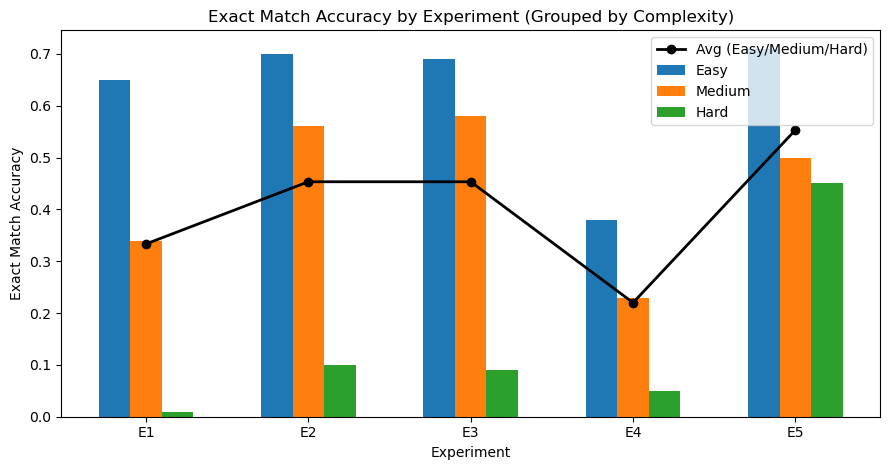

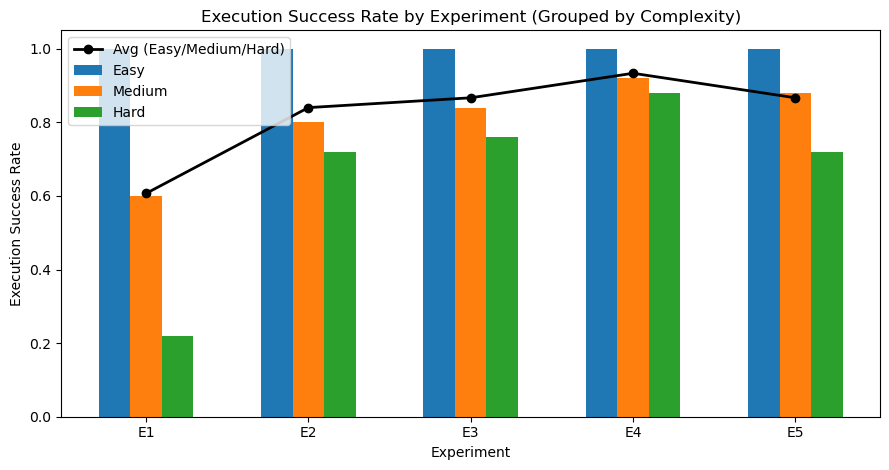

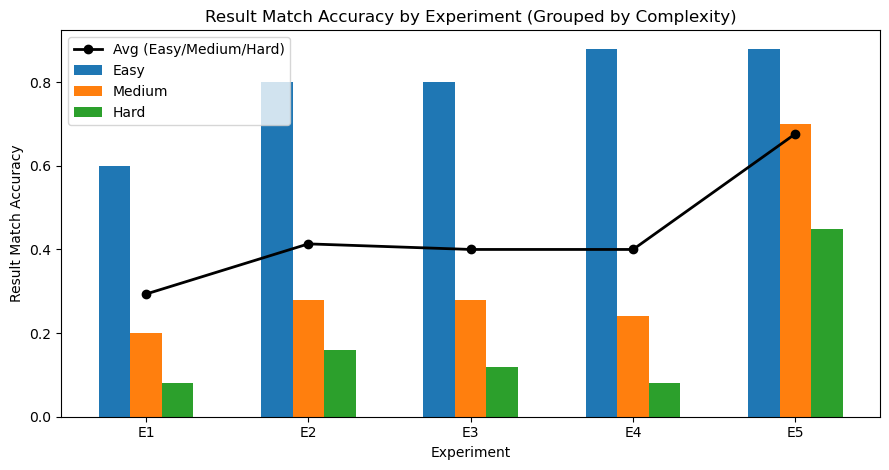

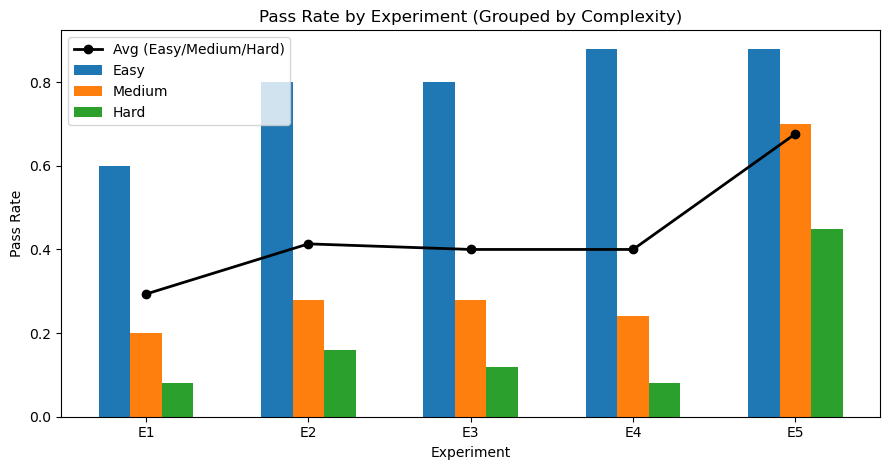

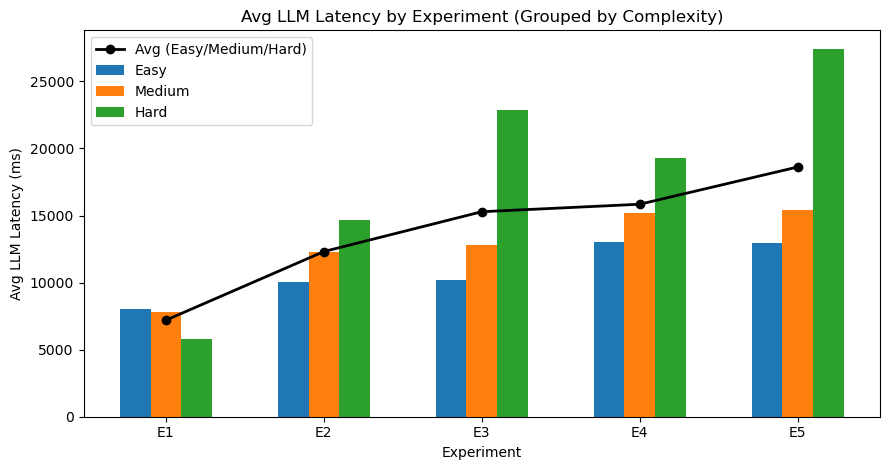

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# 1) Input dataset
# -------------------------
rows = [
    ("E1","Easy",  0.65,1.00,0.60,0.60, 8043),
    ("E1","Medium",0.34,0.60,0.20,0.20, 7788),
    ("E1","Hard",  0.01,0.22,0.08,0.08, 5763),

    ("E2","Easy",  0.70,1.00,0.80,0.80,10007),
    ("E2","Medium",0.56,0.80,0.28,0.28,12273),
    ("E2","Hard",  0.10,0.72,0.16,0.16,14666),

    ("E3","Easy",  0.69,1.00,0.80,0.80,10191),
    ("E3","Medium",0.58,0.84,0.28,0.28,12784),
    ("E3","Hard",  0.09,0.76,0.12,0.12,22878),

    # NOTE: Using the values from your latest dataset text.
    # If you want the earlier screenshot values for E4 latency (5171/6060/6763),
    # replace the three latency numbers below accordingly.
    ("E4","Easy",  0.38,1.00,0.88,0.88,13024),
    ("E4","Medium",0.23,0.92,0.24,0.24,15220),
    ("E4","Hard",  0.05,0.88,0.08,0.08,19282),

    ("E5","Easy",  0.71,1.00,0.88,0.88,12987),
    ("E5","Medium",0.50,0.88,0.70,0.70,15434),
    ("E5","Hard",  0.45,0.72,0.45,0.45,27435),
]

cols = ["Experiment","Complexity","ExactMatch","ExecutionSuccess","ResultMatch","PassRate","Latency"]
df = pd.DataFrame(rows, columns=cols)

experiments = ["E1","E2","E3","E4","E5"]
complexities = ["Easy","Medium","Hard"]

# Different color for each complexity (you can change these if you want)
colors = {"Easy":"#1f77b4", "Medium":"#ff7f0e", "Hard":"#2ca02c"}

# -------------------------
# 2) Plot helper
# -------------------------
def plot_grouped(metric: str, ylabel: str, title: str):
    # Pivot to shape: rows=Experiment, cols=Complexity
    pivot = df.pivot(index="Experiment", columns="Complexity", values=metric).loc[experiments, complexities]
    avgs = pivot.mean(axis=1)

    # More gap between experiments (group spacing)
    group_gap = 1.8
    x = np.arange(len(experiments)) * group_gap

    # 3 nearby bars per experiment
    bar_w = 0.35
    offsets = {"Easy": -bar_w, "Medium": 0.0, "Hard": bar_w}

    plt.figure(figsize=(9, 4.8))

    # Bars by complexity
    for c in complexities:
        plt.bar(
            x + offsets[c],
            pivot[c].values,
            width=bar_w,
            label=c,
            color=colors[c]
        )

    # Average point (mean of 3 complexities) + connecting line
    plt.plot(
        x,
        avgs.values,
        marker="o",
        linewidth=2,
        color="black",
        label="Avg (Easy/Medium/Hard)"
    )

    # Labels/ticks
    plt.title(title)
    plt.xlabel("Experiment")
    plt.ylabel(ylabel)
    plt.xticks(x, experiments)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# 3) Generate charts for each metric
# -------------------------
plot_grouped("ExactMatch",       "Exact Match Accuracy",        "Exact Match Accuracy by Experiment (Grouped by Complexity)")
plot_grouped("ExecutionSuccess", "Execution Success Rate",      "Execution Success Rate by Experiment (Grouped by Complexity)")
plot_grouped("ResultMatch",      "Result Match Accuracy",       "Result Match Accuracy by Experiment (Grouped by Complexity)")
plot_grouped("PassRate",         "Pass Rate",                   "Pass Rate by Experiment (Grouped by Complexity)")
plot_grouped("Latency",          "Avg LLM Latency (ms)",        "Avg LLM Latency by Experiment (Grouped by Complexity)")
